In [1]:
import os
import ast
import pandas as pd
import networkx as nx
from tqdm import tqdm
import matplotlib.pyplot as plt

tqdm.pandas()

df_cookies_top5_cluster = pd.read_csv(os.path.join(os.getcwd(), 'top5_cluster_to_cookies.csv'))
df_cookies_top5_cluster.head()

,id,cookie,number_of_sites
0,8e087d38-fdcc-4ce5-b619-7a69cfa53af6,_ga,5141
1,8e087d38-fdcc-4ce5-b619-7a69cfa53af6,statid,5141
2,8e087d38-fdcc-4ce5-b619-7a69cfa53af6,AMCV,5141
3,8e087d38-fdcc-4ce5-b619-7a69cfa53af6,yv_iid,5141
4,8e087d38-fdcc-4ce5-b619-7a69cfa53af6,yuid,5141


In [2]:
list_of_cookies = list(set(df_cookies_top5_cluster['cookie'].tolist()))
df_grouped = df_cookies_top5_cluster.groupby('cookie')

edges = list()

for cookie in tqdm(list_of_cookies, total=len(list_of_cookies), desc='Building edge set...'):
    _df = df_grouped.get_group(cookie)
    for id in list(set(_df['id'].tolist())):
        edges.append((cookie, id))

print("Build ", len(edges), "edge set.")

Building edge set...: 100%|██████████| 978/978 [00:00<00:00, 14806.85it/s]

Build  2744 edge set.


In [3]:
cluster_to_site_data = dict()
for index, row in df_cookies_top5_cluster.iterrows():
    id = row['id']
    number_of_sites = row['number_of_sites']
    cluster_to_site_data[id] = number_of_sites
print("Build", len(cluster_to_site_data), "clusters.")

Build 5 clusters.


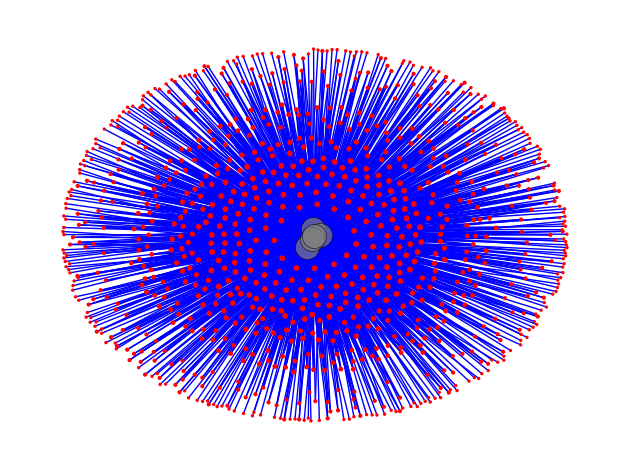

In [4]:
G = nx.Graph()

cluster_set = list(set(df_cookies_top5_cluster['id']))

G.add_edges_from(edges)

pos = nx.spring_layout(
    G,
    k=2,
    scale=150,
    iterations=300,
    seed=3113794652
)


cookie_degrees = {node: G.degree(node) for node in list_of_cookies}
node_sizes_cookies = [cookie_degrees[node] * 2 for node in list_of_cookies]
node_sizes_clusters = [1 for cluster in cluster_set]#[cluster_to_site_data[cluster] * 1 for cluster in cluster_set]

nx.draw_networkx_nodes(G, pos=pos, nodelist=list_of_cookies, node_color='red', node_size=node_sizes_cookies)
nx.draw_networkx_nodes(G, pos=pos, nodelist=cluster_set, node_color='grey', alpha=0.7, edgecolors='black', linewidths=0.5)

nx.draw_networkx_edges(G, pos=pos, edgelist=edges, edge_color='blue')

plt.tight_layout()
plt.axis('off')
plt.savefig("Ecosystem_Top_5_Cluster.pdf", format='pdf', orientation='landscape')
plt.show()

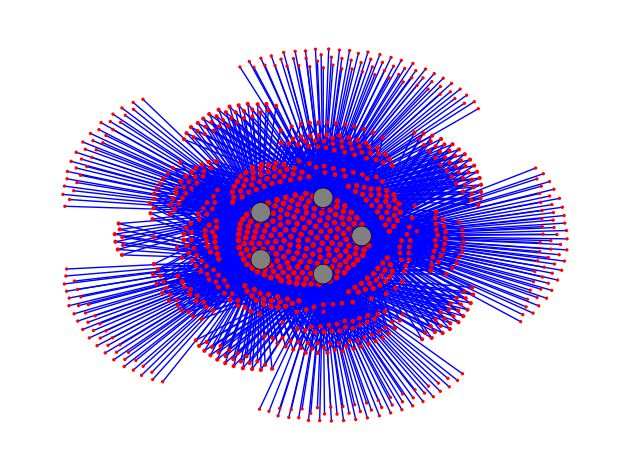

In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
cluster_set = list(set(df_cookies_top5_cluster['id']))
G.add_edges_from(edges)

# --- 1) Deterministically place the 5 cluster nodes with minimum distance ---
# Put them on a circle around the origin so they never overlap.
R = 5.0  # increase R => more distance between grey nodes
angles = np.linspace(0, 2*np.pi, len(cluster_set), endpoint=False)

cluster_pos = {
    n: np.array([R*np.cos(a), R*np.sin(a)])
    for n, a in zip(cluster_set, angles)
}

# --- 2) Provide an initial position for all other nodes (cookies) ---
# Start all other nodes near the origin (or random jitter).
init_pos = dict(cluster_pos)
rng = np.random.default_rng(3113794652)
for n in G.nodes():
    if n not in init_pos:
        init_pos[n] = rng.normal(loc=0.0, scale=0.5, size=2)

# --- 3) Run spring layout but keep cluster nodes fixed ---
pos = nx.spring_layout(
    G,
    pos=init_pos,
    fixed=cluster_set,        # <--- key: grey nodes do not move
    k=2,
    iterations=300,
    seed=3113794652
)

# --- Draw ---
cookie_degrees = {node: G.degree(node) for node in list_of_cookies}
node_sizes_cookies = [cookie_degrees[node] * 2 for node in list_of_cookies]
node_sizes_clusters = [200 for _ in cluster_set]  # make clusters visible (tune as needed)

nx.draw_networkx_nodes(G, pos, nodelist=list_of_cookies, node_color='red', node_size=node_sizes_cookies)
nx.draw_networkx_nodes(G, pos, nodelist=cluster_set, node_color='grey', node_size=node_sizes_clusters,
                       alpha=1, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='blue')

plt.tight_layout()
plt.axis('off')
plt.savefig("Ecosystem_Top_5_Cluster_diff_layout.pdf", format='pdf', orientation='landscape')
plt.show()